# 🔍 Object Detection — SSDLite + MobileNetV3
**Dataset:** CVAT YOLO 1.1 export (1 class)  
**Model:** `ssdlite320_mobilenet_v3_large` (torchvision)  
**Framework:** PyTorch

### Expected dataset layout
```
dataset/
  images/
    row_001.jpg
    row_002.jpg
  labels/
    row_001.txt   # YOLO format: class cx cy w h (normalized)
    row_002.txt
```

## 1 · Install & imports

In [1]:
import os, glob, random, time, copy
from pathlib import Path

import torch
import torchvision
from torchvision.models.detection import ssdlite320_mobilenet_v3_large, SSDLite320_MobileNet_V3_Large_Weights
from torchvision.models.detection.ssdlite import SSDLiteClassificationHead
from torchvision import transforms as T

import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print(f"PyTorch  : {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device   : {DEVICE}")

PyTorch  : 2.12.0+cu130
Torchvision: 0.27.0+cu130
CUDA available: False
Device   : cpu


## 2 · Configuration

In [2]:
# ── Edit these ──────────────────────────────────────────────
DATASET_ROOT = '../../datasets/dataset'        # path to your dataset folder
CLASS_NAMES  = ['plant']         # your 1 class name(s)
VAL_SPLIT    = 0.15               # fraction used for validation
SEED         = 42

# Training
NUM_EPOCHS   = 30
BATCH_SIZE   = 8
LR           = 1e-3
LR_STEP      = 20                 # decay LR at this epoch
LR_GAMMA     = 0.1
NUM_WORKERS  = 2

# SSD input size (fixed at 320 for ssdlite320)
INPUT_SIZE   = 320

# Number of classes = your classes + 1 background
NUM_CLASSES  = len(CLASS_NAMES) + 1
# ─────────────────────────────────────────────────────────────

random.seed(SEED)
torch.manual_seed(SEED)
print(f"Classes (incl. background): {NUM_CLASSES}")

Classes (incl. background): 2


## 3 · Dataset

In [3]:
class YOLODetectionDataset(torch.utils.data.Dataset):
    """
    Reads CVAT YOLO 1.1 labels (class cx cy w h  — all normalized 0-1).
    Returns images as float tensors [3,H,W] and targets as dicts
    compatible with torchvision detection models.
    """

    def __init__(self, image_paths, label_paths, transforms=None):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.transforms  = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        w, h = img.size

        boxes, labels = [], []
        lp = self.label_paths[idx]

        if os.path.exists(lp):
            with open(lp) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls, cx, cy, bw, bh = map(float, parts[:5])
                    # convert YOLO → xyxy (absolute pixels)
                    x1 = (cx - bw / 2) * w
                    y1 = (cy - bh / 2) * h
                    x2 = (cx + bw / 2) * w
                    y2 = (cy + bh / 2) * h
                    x1, y1 = max(0, x1), max(0, y1)
                    x2, y2 = min(w, x2), min(h, y2)
                    if x2 > x1 and y2 > y1:
                        boxes.append([x1, y1, x2, y2])
                        labels.append(int(cls) + 1)  # +1 for background

        if len(boxes) == 0:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,),   dtype=torch.int64)
        else:
            boxes  = torch.tensor(boxes,  dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            'boxes' : boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target


# ── Collect all samples ───────────────────────────────────────
img_dir = Path(DATASET_ROOT) / 'images'
lbl_dir = Path(DATASET_ROOT) / 'labels'

img_paths = sorted([
    str(p) for p in img_dir.glob('*')
    if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
])

lbl_paths = [
    str(lbl_dir / (Path(p).stem + '.txt'))
    for p in img_paths
]

print(f"Found {len(img_paths)} images")

# ── Train / Val split ─────────────────────────────────────────
indices = list(range(len(img_paths)))
random.shuffle(indices)
n_val  = max(1, int(len(indices) * VAL_SPLIT))
val_idx   = indices[:n_val]
train_idx = indices[n_val:]

def make_subset(idx_list):
    return [img_paths[i] for i in idx_list], [lbl_paths[i] for i in idx_list]

train_imgs, train_lbls = make_subset(train_idx)
val_imgs,   val_lbls   = make_subset(val_idx)
print(f"Train: {len(train_imgs)}  |  Val: {len(val_imgs)}")

# ── Transforms ────────────────────────────────────────────────
# SSDLite320 expects a float tensor in [0,1]; internal normalisation
# is handled by the model's transform layer.
train_tf = T.Compose([
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
])
val_tf = T.Compose([T.ToTensor()])

train_ds = YOLODetectionDataset(train_imgs, train_lbls, transforms=train_tf)
val_ds   = YOLODetectionDataset(val_imgs,   val_lbls,   transforms=val_tf)

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=collate_fn)
val_loader   = torch.utils.data.DataLoader(
    val_ds,   batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_fn)

print('DataLoaders ready ✓')

Found 263 images
Train: 224  |  Val: 39
DataLoaders ready ✓


## 4 · Quick dataset sanity check

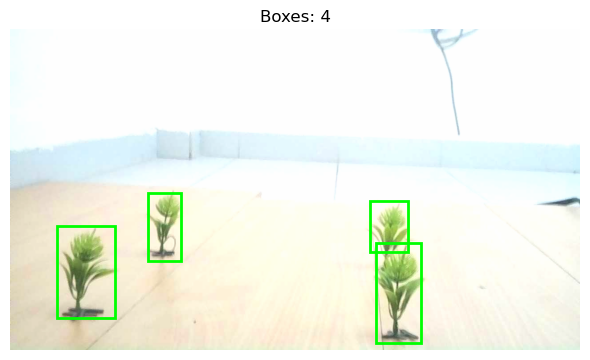

In [4]:
def show_sample(dataset, idx=0):
    img_tensor, target = dataset[idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(img_np)
    for box in target['boxes']:
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
    ax.set_title(f'Boxes: {len(target["boxes"])}')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

show_sample(train_ds, idx=100)

## 5 · Build model

In [5]:
# Load pretrained weights (COCO) then replace the head for our NUM_CLASSES
weights = SSDLite320_MobileNet_V3_Large_Weights.COCO_V1
model   = ssdlite320_mobilenet_v3_large(weights=weights)

# Replace classification head — robust across torchvision versions
# Walk each prediction module and grab the first Conv2d's in_channels
def _first_conv_in_channels(module):
    for m in module.modules():
        if isinstance(m, torch.nn.Conv2d):
            return m.in_channels
    raise ValueError(f'No Conv2d found in {module}')

in_channels = [_first_conv_in_channels(m)
               for m in model.head.classification_head.module_list]
num_anchors = model.anchor_generator.num_anchors_per_location()

model.head.classification_head = SSDLiteClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=NUM_CLASSES,
    norm_layer=torch.nn.BatchNorm2d
)

model.to(DEVICE)
print('Model ready ✓')
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Model ready ✓
Total parameters: 2,206,520


## 6 · Optimizer & scheduler

In [6]:
# Fine-tune everything (backbone + head)
params     = [p for p in model.parameters() if p.requires_grad]
optimizer  = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)
print('Optimizer: SGD  |  Scheduler: StepLR')

Optimizer: SGD  |  Scheduler: StepLR


## 7 · Training loop

In [ ]:
history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
best_weights  = None

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    n_batches  = 0

    for images, targets in loader:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        # Skip batches where all images have no boxes
        if all(t['boxes'].shape[0] == 0 for t in targets):
            continue

        if train:
            loss_dict = model(images, targets)
            losses    = sum(loss_dict.values())
            optimizer.zero_grad()
            losses.backward()
            torch.nn.utils.clip_grad_norm_(params, max_norm=5.0)
            optimizer.step()
            total_loss += losses.item()
        else:
            # eval mode: temporarily switch to train to get losses
            model.train()
            with torch.no_grad():
                loss_dict = model(images, targets)
                losses    = sum(loss_dict.values())
            model.eval()
            total_loss += losses.item()

        n_batches += 1

    return total_loss / max(n_batches, 1)


print(f'Starting training for {NUM_EPOCHS} epochs on {DEVICE}\n')
print(f'{"Epoch":>6}  {"Train Loss":>12}  {"Val Loss":>10}  {"LR":>10}  {"Time":>8}')
print('-' * 56)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    elapsed = time.time() - t0
    lr_now  = scheduler.get_last_lr()[0]
    tag     = '  ← best' if val_loss < best_val_loss else ''

    print(f'{epoch:>6}  {train_loss:>12.4f}  {val_loss:>10.4f}  {lr_now:>10.2e}  {elapsed:>6.1f}s{tag}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = copy.deepcopy(model.state_dict())

print('\nTraining complete ✓')

Starting training for 30 epochs on cpu

 Epoch    Train Loss    Val Loss          LR      Time
--------------------------------------------------------


     1        7.0228      4.9150    1.00e-03   187.5s  ← best
     2        4.2472      3.6507    1.00e-03   177.1s  ← best
     3        3.3102      3.0579    1.00e-03   176.9s  ← best
     4        2.8685      2.7705    1.00e-03   178.6s  ← best
     5        2.5488      2.5316    1.00e-03   176.3s  ← best
     6        2.3319      2.3946    1.00e-03   179.8s  ← best
     7        2.1470      2.2670    1.00e-03   175.4s  ← best
     8        1.9851      2.1738    1.00e-03   179.7s  ← best
     9        1.8848      2.1035    1.00e-03   179.0s  ← best
    10        1.7807      2.1165    1.00e-03   176.9s
    11        1.6836      2.0669    1.00e-03   181.8s  ← best
    12        1.6383      2.0248    1.00e-03   177.9s  ← best
    13        1.5331      2.0155    1.00e-03   175.3s  ← best
    14        1.4700      1.9814    1.00e-03   178.8s  ← best
    15        1.3906      1.9744    1.00e-03   175.8s  ← best
    16        1.3400      1.9601    1.00e-03   179.3s  ← best
    17        1.

## 8 · Loss curves

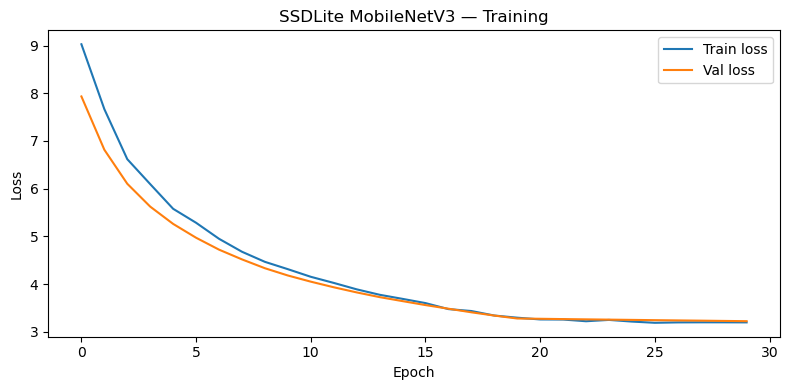

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'],   label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SSDLite MobileNetV3 — Training')
plt.legend()
plt.tight_layout()
plt.show()

## 9 · Save best model

In [ ]:
SAVE_PATH = 'v4_ssdlite_mobilenetv3.pth'

model.load_state_dict(best_weights)
torch.save({
    'model_state_dict': best_weights,
    'num_classes'     : NUM_CLASSES,
    'class_names'     : CLASS_NAMES,
    'val_loss'        : best_val_loss,
}, SAVE_PATH)

print(f'Saved → {SAVE_PATH}  (val_loss={best_val_loss:.4f})')

Saved → v3_ssdlite_mobilenetv3.pth  (val_loss=3.2212)


## 10 · Inference on a sample image

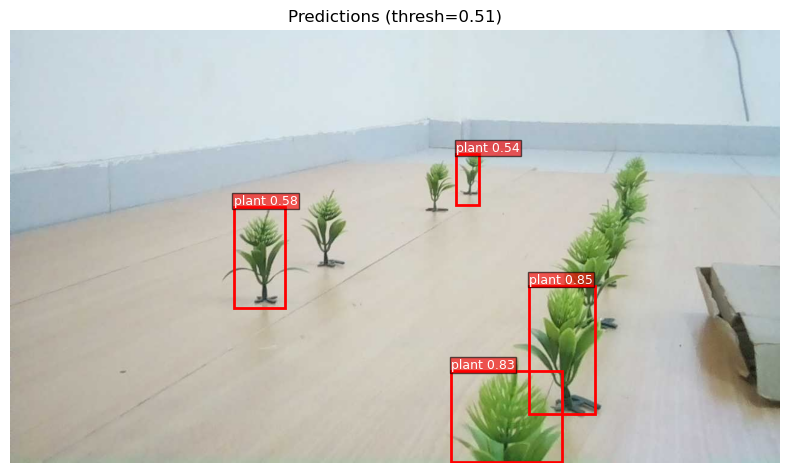

In [ ]:
SCORE_THRESH = 0.51   # confidence threshold

model.eval()
img_path   = val_imgs[0]
img_pil    = Image.open(img_path).convert('RGB')
img_tensor = T.ToTensor()(img_pil).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    preds = model(img_tensor)[0]

fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(img_pil)

for box, label, score in zip(preds['boxes'], preds['labels'], preds['scores']):
    if score < SCORE_THRESH:
        continue
    x1, y1, x2, y2 = box.tolist()
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    cls_name = CLASS_NAMES[label.item() - 1] if label.item() > 0 else 'bg'
    ax.text(x1, y1 - 4, f'{cls_name} {score:.2f}',
            color='white', fontsize=9,
            bbox=dict(facecolor='red', alpha=0.6, pad=1))

ax.set_title(f'Predictions (thresh={SCORE_THRESH})')
ax.axis('off')
plt.tight_layout()
plt.show()

## 11 · (Optional) Export to TorchScript / ONNX
Uncomment whichever you need.

In [ ]:
# ── TorchScript ───────────────────────────────────────────────
# scripted = torch.jit.script(model)
# scripted.save('ssdlite_mobilenetv3.torchscript')
# print('TorchScript saved ✓')

# ── ONNX ──────────────────────────────────────────────────────
# dummy = torch.randn(1, 3, 320, 320).to(DEVICE)
# torch.onnx.export(
#     model, dummy, 'ssdlite_mobilenetv3.onnx',
#     opset_version=11,
#     input_names=['input'],
#     output_names=['boxes', 'labels', 'scores'])
# print('ONNX saved ✓')

print('Uncomment an export option above and re-run.')

In [ ]:
import functools

TRAINED_PATH = "/home/eath/my_ros_bot/src/move_base/tools/mobilenet/best_ssdlite_mobilenetv3.pth"
OUTPUT_PATH  = "/home/eath/my_ros_bot/src/move_base/tools/mobilenet/plant_detector_v4.onnx"
NUM_CLASSES  = 2          # background + plant
DEVICE       = torch.device("cpu")   # export on CPU for maximum compatibility
IMG_H, IMG_W = 720, 1280              # SSDLite320 fixed input size

# ── Build model ───────────────────────────────────────────────
print("Building model …")
weights_backbone = SSDLite320_MobileNet_V3_Large_Weights.DEFAULT
model = ssdlite320_mobilenet_v3_large(weights=weights_backbone)

in_channels = [c[-1].in_channels for c in model.head.classification_head.module_list]
num_anchors  = model.anchor_generator.num_anchors_per_location()
model.head.classification_head = SSDLiteClassificationHead(
    in_channels,
    num_anchors,
    NUM_CLASSES,
    norm_layer=functools.partial(torch.nn.BatchNorm2d, eps=0.001, momentum=0.03),
)

Building model …


In [ ]:
checkpoint = torch.load(TRAINED_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE).eval()
print("Checkpoint loaded ✓")

Checkpoint loaded ✓


In [ ]:
class DetectionWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        # x: (1, 3, H, W)  — batch size fixed to 1
        preds = self.model(x)          # list of dicts, length == batch size
        pred  = preds[0]
        return (
            pred["boxes"],             # (N, 4)  float32
            pred["labels"],            # (N,)    int64
            pred["scores"],            # (N,)    float32
        )

wrapped = DetectionWrapper(model).eval()

In [ ]:
dummy = torch.zeros(1, 3, IMG_H, IMG_W, dtype=torch.float32)

# Quick sanity check
with torch.no_grad():
    boxes, labels, scores = wrapped(dummy)
print(f"Sanity check — dummy output shapes: boxes={boxes.shape}, labels={labels.shape}, scores={scores.shape}")


Sanity check — dummy output shapes: boxes=torch.Size([104, 4]), labels=torch.Size([104]), scores=torch.Size([104])


In [ ]:
torch.onnx.export(
    wrapped,
    dummy,
    OUTPUT_PATH,
    opset_version=17,
    input_names=["image"],
    output_names=["boxes", "labels", "scores"],
    dynamic_axes={
        "boxes":  {0: "num_detections"},
        "labels": {0: "num_detections"},
        "scores": {0: "num_detections"},
    },
    do_constant_folding=True,
    verbose=False,
    dynamo=False,   # ← force legacy exporter, bypasses the NMS tracing issue
)

/tmp/ipykernel_32237/4226033015.py:1: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/home/eath/.conda/envs/ml_stuff/lib/python3.11/site-packages/torchvision/ops/boxes.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  boxes_x = torch.min(boxes_x, torch.tensor(width, dtype=boxes.dtype, device=boxes.device))
/home/eath/.conda/envs/ml_stuff/lib/python3.11/site-packages/torchvision/ops/boxes.py:176: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach(

In [ ]:
try:
    import onnxruntime as ort
    import numpy as np

    sess = ort.InferenceSession(OUTPUT_PATH, providers=["CPUExecutionProvider"])
    dummy_np = np.zeros((1, 3, IMG_H, IMG_W), dtype=np.float32)
    out = sess.run(None, {"image": dummy_np})
    print(f"ONNX Runtime verification ✓")
    print(f"  boxes  : {out[0].shape}")
    print(f"  labels : {out[1].shape}")
    print(f"  scores : {out[2].shape}")
    print(f"\nAll good! Copy {OUTPUT_PATH} to your ROS workspace.")
except ImportError:
    print("onnxruntime not installed — skipping verification.")
    print("Install with:  pip install onnxruntime")

ONNX Runtime verification ✓
  boxes  : (104, 4)
  labels : (104,)
  scores : (104,)

All good! Copy /home/eath/my_ros_bot/src/move_base/tools/mobilenet/plant_detector_v3.onnx to your ROS workspace.
